In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
data = pd.read_csv(r"C:\Users\prera\Downloads\airlines_flights_data.csv")

In [7]:
data

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


## **Cleaning Data**


In [8]:
data.drop( columns = 'index', inplace = True)

In [9]:
data

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [10]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [11]:
data.describe()


,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [12]:
data.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [13]:
data.drop_duplicates(inplace=True)


In [14]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [16]:
data['airline'].value_counts()


airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

### **Q.1 What are the airlines in the dataset, accompanied by their frequencies?**

In [19]:
data['airline'].nunique()

6

In [20]:
data['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [21]:
data['airline'].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

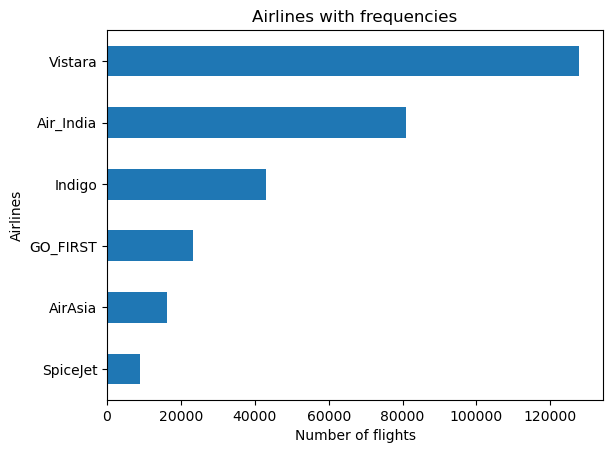

In [27]:
data['airline'].value_counts(ascending=True).plot.barh()
plt.title("Airlines with frequencies")
plt.xlabel("Number of flights")
plt.ylabel("Airlines")
plt.show()

## **Q.2. Show Bar Graphs representing the Departure Time & Arrival Time.**

In [28]:
data.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [30]:
data['departure_time'].value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [31]:
data['arrival_time'].value_counts()

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

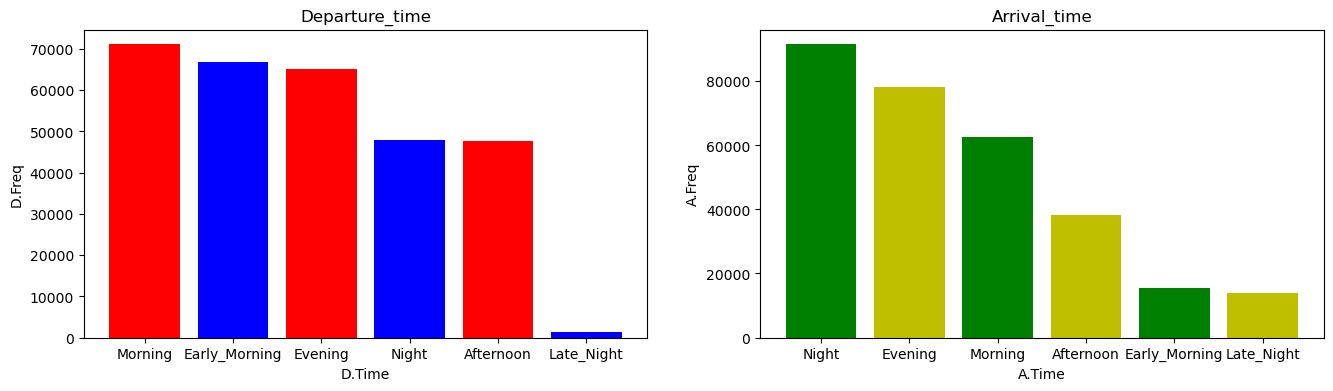

In [47]:
plt.figure(figsize = (16,4))
plt.subplot(1,2,1)

plt.bar(data['departure_time'].value_counts().index , data['departure_time'].value_counts().values, color = ['r','b'])
plt.title("Departure_time")
plt.xlabel("D.Time")
plt.ylabel("D.Freq")

plt.subplot(1,2,2)

plt.bar(data['arrival_time'].value_counts().index , data['arrival_time'].value_counts().values, color = ['g','y'])
plt.title("Arrival_time")
plt.xlabel("A.Time")
plt.ylabel("A.Freq")

plt.show()

### **Q.3. Show Bar Graphs representing the Source City & Destination City.**

In [41]:
data.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [44]:
data['destination_city'].value_counts()

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

In [46]:
data['source_city'].value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

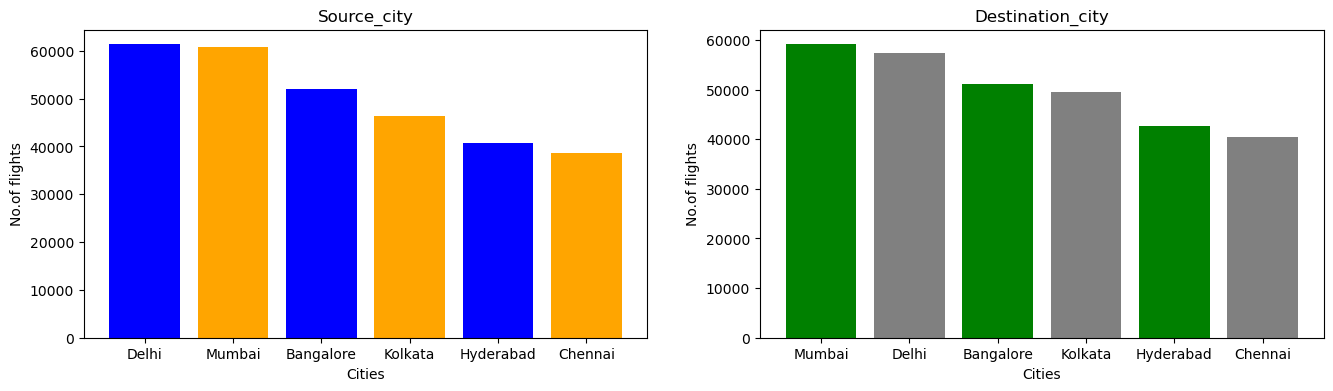

In [56]:
plt.figure(figsize = (16,4))
plt.subplot(1,2,1)

plt.bar(data['source_city'].value_counts().index , data['source_city'].value_counts().values, color = ['blue','orange'])
plt.title("Source_city")
plt.xlabel("Cities")
plt.ylabel("No.of flights")

plt.subplot(1,2,2)

plt.bar(data['destination_city'].value_counts().index , data['destination_city'].value_counts().values, color = ['green','grey'])
plt.title("Destination_city")
plt.xlabel("Cities")
plt.ylabel("No.of flights")
plt.show()

### **Q.4. Does price varies with airlines ?**

In [57]:
data.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [60]:
data.groupby('airline')['price'].mean()

airline
AirAsia       4091.072742
Air_India    23507.019112
GO_FIRST      5652.007595
Indigo        5324.216303
SpiceJet      6179.278881
Vistara      30396.536302
Name: price, dtype: float64

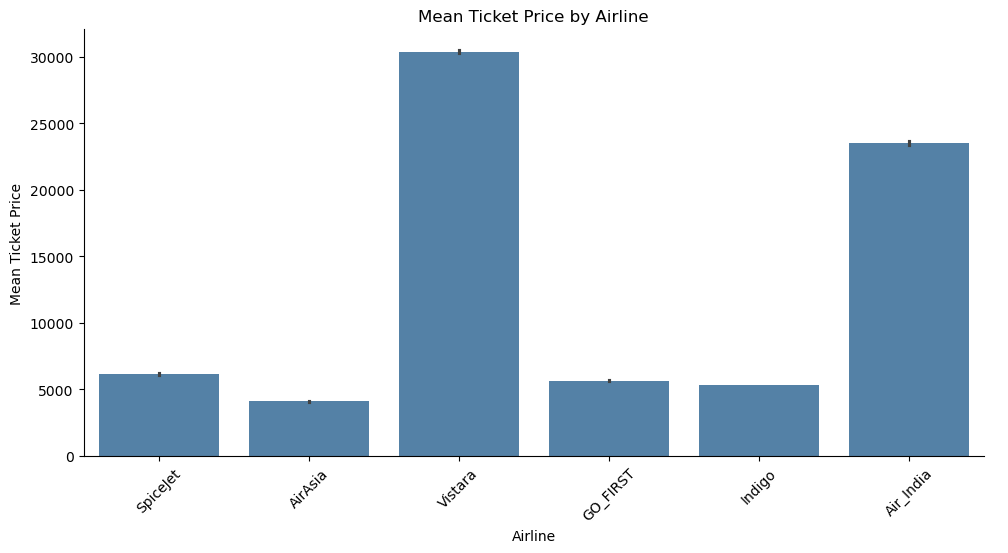

In [62]:
sns.catplot(
    x='airline',
    y='price',
    data=data,
    kind='bar',
    height=5,
    aspect=2,
    color='steelblue'
)

plt.xticks(rotation=45)
plt.xlabel("Airline")
plt.ylabel("Mean Ticket Price")
plt.title("Mean Ticket Price by Airline")
plt.show()


### **Q.5. Does ticket price change based on the departure time and arrival time?**

In [63]:
data.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [64]:
data.groupby('departure_time')['price'].mean().sort_values()


departure_time
Late_Night        9295.299387
Afternoon        18179.203331
Early_Morning    20370.676718
Evening          21232.361894
Morning          21630.760254
Night            23062.146808
Name: price, dtype: float64

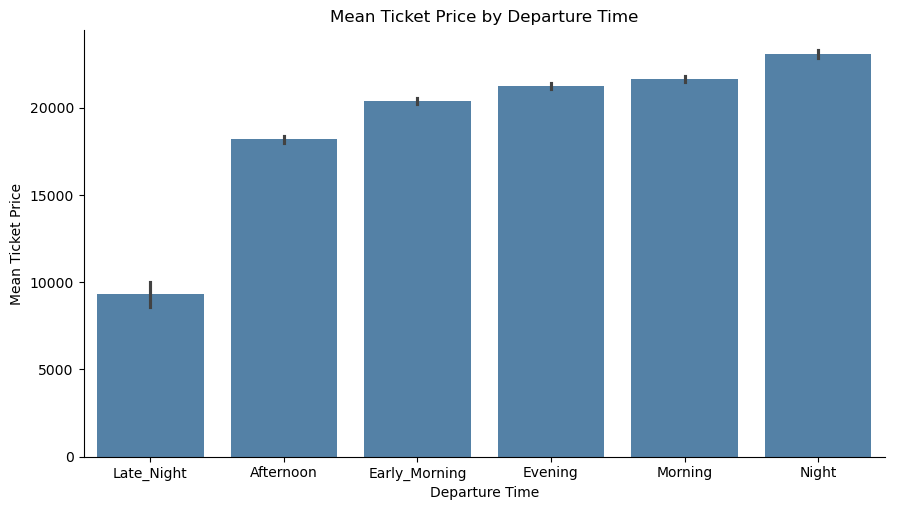

In [65]:
order = data.groupby('departure_time')['price'].mean().sort_values().index

sns.catplot(
    x='departure_time',
    y='price',
    data=data,
    kind='bar',
    order=order,
    height=5,
    aspect=1.8,
    color='steelblue'
)

plt.xlabel("Departure Time")
plt.ylabel("Mean Ticket Price")
plt.title("Mean Ticket Price by Departure Time")
plt.show()


In [66]:
data.groupby('arrival_time')['price'].mean().sort_values()


arrival_time
Late_Night       11284.906078
Early_Morning    14993.139521
Afternoon        18494.598993
Night            21586.758341
Morning          22231.076098
Evening          23044.371615
Name: price, dtype: float64

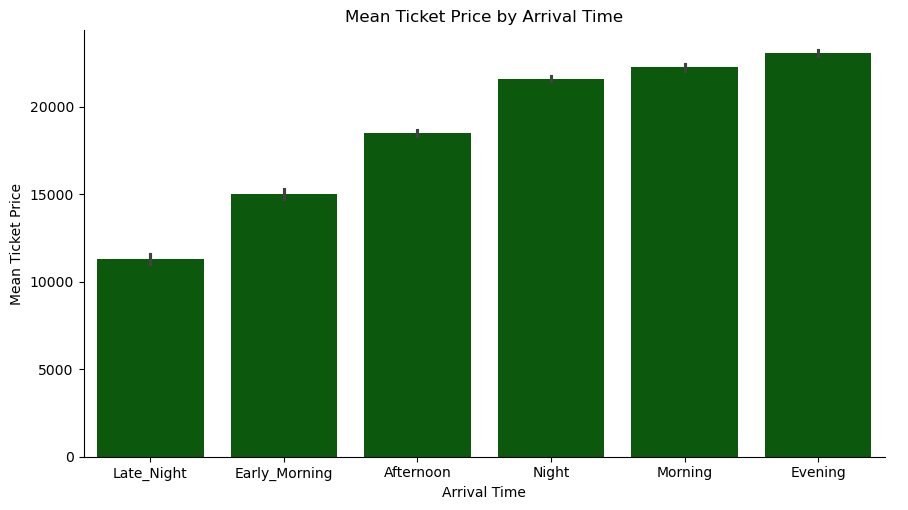

In [67]:
order = data.groupby('arrival_time')['price'].mean().sort_values().index

sns.catplot(
    x='arrival_time',
    y='price',
    data=data,
    kind='bar',
    order=order,
    height=5,
    aspect=1.8,
    color='darkgreen'
)

plt.xlabel("Arrival Time")
plt.ylabel("Mean Ticket Price")
plt.title("Mean Ticket Price by Arrival Time")
plt.show()


### **Q.6. How the price changes with change in Source and Destination?**

In [68]:
data.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [69]:
data.groupby('source_city')['price'].mean().sort_values()


source_city
Delhi        18951.326639
Hyderabad    20155.623879
Bangalore    21469.460575
Mumbai       21483.818839
Kolkata      21746.235679
Chennai      21995.339871
Name: price, dtype: float64

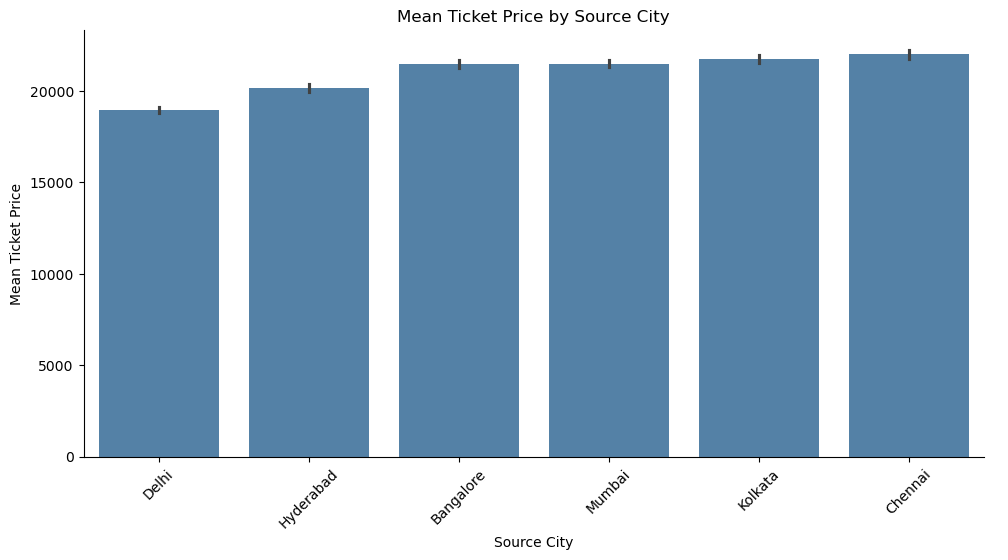

In [70]:
order = data.groupby('source_city')['price'].mean().sort_values().index

sns.catplot(
    x='source_city',
    y='price',
    data=data,
    kind='bar',
    order=order,
    height=5,
    aspect=2,
    color='steelblue'
)

plt.xlabel("Source City")
plt.ylabel("Mean Ticket Price")
plt.title("Mean Ticket Price by Source City")
plt.xticks(rotation=45)
plt.show()


In [71]:
data.groupby('destination_city')['price'].mean().sort_values()


destination_city
Delhi        18436.767870
Hyderabad    20427.661284
Mumbai       21372.529469
Bangalore    21593.955784
Chennai      21953.323969
Kolkata      21959.557556
Name: price, dtype: float64

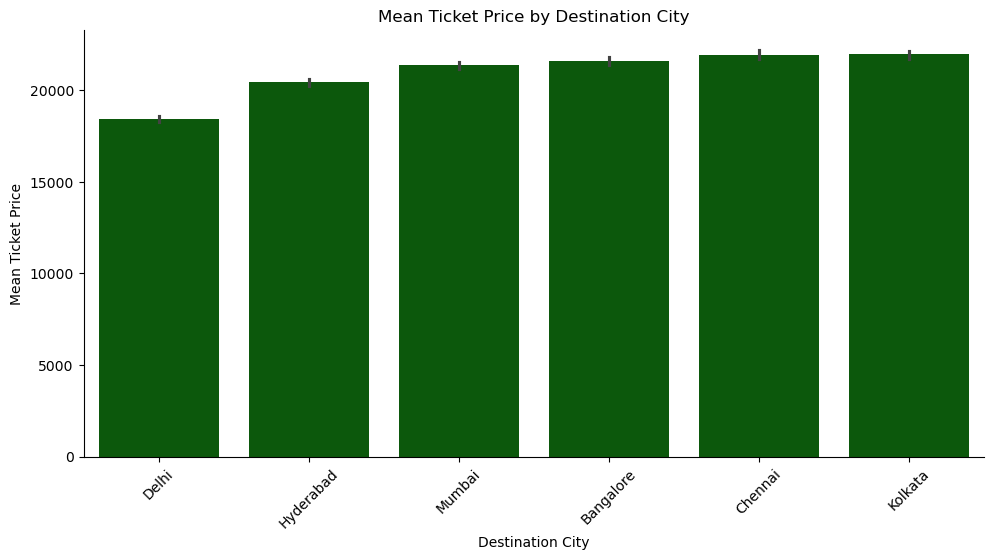

In [72]:
order = data.groupby('destination_city')['price'].mean().sort_values().index

sns.catplot(
    x='destination_city',
    y='price',
    data=data,
    kind='bar',
    order=order,
    height=5,
    aspect=2,
    color='darkgreen'
)

plt.xlabel("Destination City")
plt.ylabel("Mean Ticket Price")
plt.title("Mean Ticket Price by Destination City")
plt.xticks(rotation=45)
plt.show()


## **Q.7. How is the price affected when tickets are bought in just 1 or 2 days before departure?**

In [73]:
data.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [74]:
last_minute = data[data['days_left'] <= 2]


In [76]:
overall_avg_price = data['price'].mean()
last_minute_avg_price = last_minute['price'].mean()

overall_avg_price, last_minute_avg_price


(np.float64(20889.660523133203), np.float64(27421.169326390056))

In [77]:
last_minute.groupby('days_left')['price'].mean()


days_left
1    21591.867151
2    30211.299801
Name: price, dtype: float64

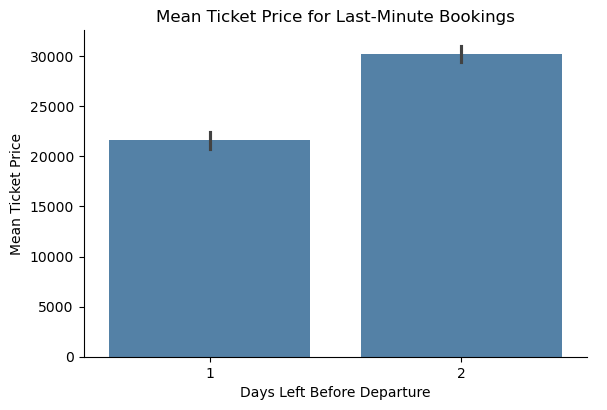

In [78]:
sns.catplot(
    x='days_left',
    y='price',
    data=last_minute,
    kind='bar',
    height=4,
    aspect=1.5,
    color='steelblue'
)

plt.xlabel("Days Left Before Departure")
plt.ylabel("Mean Ticket Price")
plt.title("Mean Ticket Price for Last-Minute Bookings")
plt.show()
